<a href="https://colab.research.google.com/github/Conscht/MNIST_Curation_Repo/blob/main/MNIST_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **MNIST Data Cleaning Task**

# **Setup**

Install all dependencies and import libraries.

In [1]:
!uv pip install fiftyone==1.7.0 torch==2.6.0 torchvision==0.21 numpy==2.0.2 open-clip-torch==3.2.0

Using Python 3.12.12 environment at: /usr
Resolved 145 packages in 1.96s
Prepared 65 packages in 1m 21s
Uninstalled 18 packages in 876ms
Installed 65 packages in 691ms
 + argcomplete==3.6.3
 + async-lru==2.0.5
 + bcrypt==5.0.0
 + boto3==1.41.1
 + botocore==1.41.1
 + choreographer==1.2.1
 + dacite==1.7.0
 + deprecated==1.3.1
 + dnspython==2.8.0
 + fiftyone==1.7.0
 + fiftyone-brain==0.21.4
 + fiftyone-db==1.4.0
 + ftfy==6.3.1
 + graphql-core==3.2.7
 + hypercorn==0.18.0
 + inflate64==1.0.3
 + jmespath==1.0.1
 + jsonlines==4.0.0
 + kaleido==1.2.0
 + lia-web==0.2.3
 + logistro==2.0.1
 + mongoengine==0.29.1
 + motor==3.6.1
 + multivolumefile==0.2.3
 - nvidia-cublas-cu12==12.6.4.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.6.80
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.6.77
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.6.77
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==9.10.2.21
 + nvidia-cudnn-cu12==9.1.0.70
 - nv

In [2]:
import fiftyone
import torch
import torchvision
import numpy
import open_clip
(fiftyone.__version__, torch.__version__,
 torchvision.__version__, numpy.__version__,
 open_clip.__version__)

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


('1.7.0', '2.6.0+cu124', '0.21.0+cu124', '2.0.2', '3.2.0')

In [3]:
import os

# Set environment variables for reproducibility BEFORE importing torch
os.environ['PYTHONHASHSEED'] = '51'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as Fun
import torchvision.transforms.v2 as transforms
import fiftyone as fo
import fiftyone.zoo as foz
import fiftyone.brain as fob
from torch.utils.data import Dataset, ConcatDataset
from fiftyone import ViewField as F
import fiftyone.utils.random as four
from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
import matplotlib.pyplot as plt
import gc
import albumentations as A
import cv2
import random
from typing import Optional, Dict, Tuple, Any

# **Task 0: Build model**

**For all following tasks, we will need a strong baseline model to solve the MNIST classification task, giving us an embedding space we can investigate.**

1. Allow deterministic reproducitbiltiy

In [4]:
def set_seeds(seed=51):
    """
    Set seeds for complete reproducibility across all libraries and operations.

    Args:
        seed (int): Random seed value
    """
    # Set environment variables before other imports
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

    # Python random module
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch CPU
    torch.manual_seed(seed)

    # PyTorch GPU (all devices)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

        # CUDA deterministic operations
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # OpenCV
    cv2.setRNGSeed(seed)

    # Albumentations (for data augmentation)
    try:
        A.seed_everything(seed)
    except AttributeError:
        # Older versions of albumentations
        pass

    # PyTorch deterministic algorithms (may impact performance)
    try:
        torch.use_deterministic_algorithms(True)
    except RuntimeError:
        # Some operations don't have deterministic implementations
        print("Warning: Some operations may not be deterministic")

    print(f"All random seeds set to {seed} for reproducibility")


def create_deterministic_training_dataloader(dataset, batch_size, shuffle=True, **kwargs):
    """
    Create a DataLoader with deterministic behavior.

    Args:
        dataset: PyTorch Dataset instance
        batch_size: Batch size
        shuffle: Whether to shuffle data
        **kwargs: Additional DataLoader arguments

    Returns:
        Training DataLoader with reproducible behavior
    """
    # Use a generator with fixed seed for reproducible shuffling
    generator = torch.Generator()
    generator.manual_seed(51)

    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        **kwargs
    )



2. Define model


I will stay with a LeNet for this example

In [5]:
class ClassicLeNet5(nn.Module):
    """
    LeNet-5 CNN architecture for MNIST digit classification.

    Original paper: "Gradient-Based Learning Applied to Document Recognition"
    by LeCun et al. (1998)

    Architecture (maintains original design with padding):
    Input (28x28) -> Pad to (32x32) -> C1 (6@28x28) -> S2 (6@14x14) ->
    C3 (16@10x10) -> S4 (16@5x5) -> C5 (120@1x1) -> F6 (84) -> Output (10)
    """

    def __init__(self, num_classes=10):
        super(ClassicLeNet5, self).__init__()

        # Feature extraction layers
        # C1: Convolutional layer - 6 feature maps, 5x5 kernels
        # Add padding=2 to convert 28x28 input to 32x32, maintaining original design
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)

        # S2: Subsampling layer (average pooling) - 2x2 with stride 2
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C3: Convolutional layer - 16 feature maps, 5x5 kernels
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)

        # S4: Subsampling layer (average pooling) - 2x2 with stride 2
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C5: Convolutional layer - 120 feature maps, 5x5 kernels (original design)
        # This reduces the 5x5 feature maps to 1x1
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)

        # Classification layers
        # F6: Fully connected layer with 84 units
        self.fc1 = nn.Linear(120, 84)

        # Output layer: 10 classes for digits 0-9
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of shape (batch_size, 1, 28, 28)

        Returns:
            Output logits of shape (batch_size, num_classes)
        """
        # C1: Convolution + activation (padding converts 28x28 to 32x32, then conv to 28x28)
        # Input: (batch, 1, 28, 28) -> Pad to (32, 32) -> Conv to (batch, 6, 28, 28)
        x = torch.tanh(self.conv1(x))

        # S2: Average pooling
        # Input: (batch, 6, 28, 28) -> Output: (batch, 6, 14, 14)
        x = self.pool1(x)

        # C3: Convolution + activation
        # Input: (batch, 6, 14, 14) -> Output: (batch, 16, 10, 10)
        x = torch.tanh(self.conv2(x))

        # S4: Average pooling
        # Input: (batch, 16, 10, 10) -> Output: (batch, 16, 5, 5)
        x = self.pool2(x)

        # C5: Convolution + activation (original 5x5 kernel design)
        # Input: (batch, 16, 5, 5) -> Output: (batch, 120, 1, 1)
        x = torch.tanh(self.conv3(x))

        # Flatten for fully connected layers
        # Input: (batch, 120, 1, 1) -> Output: (batch, 120)
        x = x.view(x.size(0), -1)

        # F6: Fully connected + activation
        # Input: (batch, 120) -> Output: (batch, 84)
        x = torch.tanh(self.fc1(x))

        # Output layer (no activation - raw logits)
        # Input: (batch, 84) -> Output: (batch, 10)
        x = self.fc2(x)

        return x

3. Build Dataset

First get the MNIST train and test split

In [6]:
train_val_dataset = foz.load_zoo_dataset("mnist",
                                         split='train',
                                         dataset_name="mnist-train-val",
                                         persistent=True)

train_val_dataset.compute_metadata()

INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/mnist/train'
100%|██████████| 9.91M/9.91M [00:00<00:00, 15.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 460kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.96MB/s]

   0% |/------------|   167/60000 [103.7ms elapsed, 37.2s remaining, 1.6K samples/s] 

 100% |█████████████| 60000/60000 [29.3s elapsed, 0s remaining, 1.8K samples/s]      


INFO:eta.core.utils: 100% |█████████████| 60000/60000 [29.3s elapsed, 0s remaining, 1.8K samples/s]      


Dataset info written to '/root/fiftyone/mnist/info.json'


...

INFO:fiftyone.zoo.datasets:Dataset 'mnist-train-val' created


Computing metadata...


INFO:fiftyone.core.metadata:Computing metadata...


 100% |█████████████| 60000/60000 [28.7s elapsed, 0s remaining, 2.4K samples/s]      


INFO:eta.core.utils: 100% |█████████████| 60000/60000 [28.7s elapsed, 0s remaining, 2.4K samples/s]      


In [7]:
test_dataset = foz.load_zoo_dataset("mnist", split='test')


INFO:fiftyone.zoo.datasets:Downloading split 'test' to '/root/fiftyone/mnist/test'
100%|██████████| 9.91M/9.91M [00:00<00:00, 15.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 459kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.99MB/s]

   2% |/------------|   209/10000 [100.9ms elapsed, 4.7s remaining, 2.1K samples/s] 

 100% |█████████████| 10000/10000 [5.4s elapsed, 0s remaining, 1.7K samples/s]      


INFO:eta.core.utils: 100% |█████████████| 10000/10000 [5.4s elapsed, 0s remaining, 1.7K samples/s]      


Dataset info written to '/root/fiftyone/mnist/info.json'


...

INFO:fiftyone.zoo.datasets:Loading 'mnist' split 'test'


 100% |█████████████| 10000/10000 [7.1s elapsed, 0s remaining, 1.5K samples/s]        


INFO:eta.core.utils: 100% |█████████████| 10000/10000 [7.1s elapsed, 0s remaining, 1.5K samples/s]        


Dataset 'mnist-test' created


INFO:fiftyone.zoo.datasets:Dataset 'mnist-test' created


Second define the train split into train and validation for training

In [8]:
train_val_dataset.untag_samples(["train", "validation"])

In [9]:
import fiftyone as fo

for name in ["mnist-training-set", "mnist-validation-set"]:
    if name in fo.list_datasets():
        fo.delete_dataset(name)

Now seed everything for reproduciability and build the training set

In [10]:
set_seeds(51)
# Create random 85%/15% split using tags
four.random_split(train_val_dataset,
                  {"train": 0.85, "validation": 0.15},
                  # The seed makes the split reproducible
                  seed=51)

# Verify the split by counting tags
tag_counts = train_val_dataset.count_sample_tags()
print("Tag counts after split:")
print(tag_counts)

# Separate validation and train FO datasets
train_dataset = train_val_dataset.match_tags("train").clone()
val_dataset = train_val_dataset.match_tags("validation").clone()

# Set names for FO datasets using the 'name' property
train_dataset.name = "mnist-training-set"
val_dataset.name = "mnist-validation-set"

# Define persistency
train_dataset.persistent = True
val_dataset.persistent = True

# Verify no overlap between train and validation
train_ids = set(train_dataset.values("id"))
val_ids = set(val_dataset.values("id"))
overlap = train_ids.intersection(val_ids)

All random seeds set to 51 for reproducibility
Tag counts after split:
{'train': 51000, 'validation': 9000}


Now build Custom Dataset Class

In [11]:
# Custom PyTorch Dataset class for MNIST training data
class CustomTorchImageDataset(torch.utils.data.Dataset):
    def __init__(self, fiftyone_dataset,
                 image_transforms=None,
                 label_map=None,
                 gt_field="ground_truth"):
        self.fiftyone_dataset = fiftyone_dataset
        self.image_paths = self.fiftyone_dataset.values("filepath")
        self.str_labels = self.fiftyone_dataset.values(f"{gt_field}.label")
        self.image_transforms = image_transforms

        if label_map is None:
            self.label_map = {str(i): i for i in range(10)}  # "0"->0, "1"->1, etc.
        else:
            self.label_map = label_map

        print(f"CustomTorchImageDataset initialized with {len(self.image_paths)} samples.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        try:
            image = Image.open(image_path).convert('L')
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            return torch.randn(1, 28, 28), torch.tensor(-1, dtype=torch.long)

        if self.image_transforms:
            image = self.image_transforms(image)

        label_str = self.str_labels[idx]
        label_idx = self.label_map.get(label_str, -1)
        if label_idx == -1:
            print(f"Warning: Label '{label_str}' not in label_map for image {image_path}")

        return image, torch.tensor(label_idx, dtype=torch.long)

Now we need to calculate normalization values to normalize our data later on for training stability

In [12]:
def compute_stats_fiftyone(fiftyone_view):
    """
    Compute stats directly from FiftyOne using aggregations.
    Requires images to be loaded as arrays.
    """

    print("Computing image intensity statistics from FiftyOne view...")

    # Get all image filepaths
    filepaths = fiftyone_view.values("filepath")

    # Load all pixel values
    all_pixels = []

    for filepath in tqdm(filepaths):

        try:
            # Load image as grayscale array
            image = Image.open(filepath).convert('L')
            # Scale values to the range [0, 1]
            pixels = np.array(image, dtype=np.float32) / 255.0
            all_pixels.append(pixels.flatten())
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            continue

    # Concatenate all pixel values
    all_pixels = np.concatenate(all_pixels)

    # Compute statistics
    mean = np.mean(all_pixels)
    std = np.std(all_pixels)

    print(f"Computed from {len(filepaths)} images")
    print(f"Total pixels: {len(all_pixels):,}")

    return mean, std

mean_intensity, std_intensity = compute_stats_fiftyone(train_dataset)
f"Mean: {mean_intensity:.4f}, Std: {std_intensity:.4f}"

Computing image intensity statistics from FiftyOne view...


100%|██████████| 51000/51000 [00:10<00:00, 5039.81it/s]


Computed from 51000 images
Total pixels: 39,984,000


'Mean: 0.1318, Std: 0.3075'

In [13]:
dataset_classes = sorted(test_dataset.distinct("ground_truth.label"))


In [14]:
label_map = {string_label: index for index, string_label in enumerate(dataset_classes)}


Normalize our data used our calculated values

In [15]:
image_transforms = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize((mean_intensity,), (std_intensity,))
])

In [62]:
torch_test_set = CustomTorchImageDataset(test_dataset,
                                          label_map=label_map,
                                          image_transforms=image_transforms)

CustomTorchImageDataset initialized with 10000 samples.


In [16]:
torch_train_set = CustomTorchImageDataset(train_dataset,
                                          label_map=label_map,
                                          image_transforms=image_transforms)

CustomTorchImageDataset initialized with 51000 samples.


In [17]:
torch_val_set = CustomTorchImageDataset(val_dataset,
                                     label_map=label_map,
                                     image_transforms=image_transforms)

CustomTorchImageDataset initialized with 9000 samples.


Fourth, set up training

In [63]:
batch_size = 64
num_workers = os.cpu_count()  # Number of CPU cores
train_loader = create_deterministic_training_dataloader(
    torch_train_set,
    batch_size=64,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    torch_val_set,
    batch_size=batch_size,
    shuffle=False, # No need to shuffle validation data
    num_workers=num_workers,
    pin_memory=True
)

print("Train and validation DataLoaders created successfully.")
print(f"Train DataLoader has {len(train_loader)} batches.")
print(f"Validation DataLoader has {len(val_loader)} batches.")



Train and validation DataLoaders created successfully.
Train DataLoader has 797 batches.
Validation DataLoader has 141 batches.


Initialize loss function and define train/val loop

In [19]:
ce_loss = nn.CrossEntropyLoss()

In [20]:
def train_epoch(model, train_loader):
  batch_losses = []
  model.train()
  for images, labels in tqdm(train_loader, desc="Training: "):
      #import pdb; pdb.set_trace()

      images = images.to(device)
      labels = labels.to(device)
      # Forward pass
      logits = model(images)
      loss_value = ce_loss(logits, labels)
      # Clear gradients from previous iteration (PyTorch accumulates by default)
      optimizer.zero_grad()
      # Computes the gradients with backpropagation
      loss_value.backward()
      # Updates the weights
      optimizer.step()

      batch_losses.append(loss_value.item())

  train_loss = np.mean(batch_losses)
  return train_loss


In [21]:
def val_epoch(model, val_loader):
  batch_losses = []
  model.eval()
  with torch.inference_mode():
    for images, labels in tqdm(val_loader, desc="Validation: "):
      images = images.to(device)
      labels = labels.to(device)
      # Forward pass
      logits = model(images)
      loss_value = ce_loss(logits, labels)
      batch_losses.append(loss_value.item())
  val_loss = np.mean(batch_losses)
  return val_loss

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"


In [23]:
model = ClassicLeNet5().to(device)

# Define the optimizer (variant of stochastic gradient descent)
optimizer = Adam(model.parameters(),
                 lr=0.003, betas=(0.9, 0.999),
                 eps=1e-08, weight_decay=0)


Train the model


In [24]:
num_epochs = 10
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model = None

# Define the path to save the model within your hard-drive
path = Path(os.getcwd()) # Feel free to change the path

model_save_path = path / 'best_lenet.pth'

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader)
    val_loss = val_epoch(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        # Save the best model
        torch.save(best_model.state_dict(), model_save_path)
        print('Found and saved better weights for the model')

Validation: 100%|██████████| 141/141 [00:06<00:00, 21.88it/s]


Epoch 1/10 - Train Loss: 0.1956 - Val Loss: 0.0849
Found and saved better weights for the model


Validation: 100%|██████████| 141/141 [00:04<00:00, 28.85it/s]


Epoch 2/10 - Train Loss: 0.0765 - Val Loss: 0.0595
Found and saved better weights for the model


Validation: 100%|██████████| 141/141 [00:04<00:00, 29.05it/s]


...

Epoch 8/10 - Train Loss: 0.0371 - Val Loss: 0.0600


Validation: 100%|██████████| 141/141 [00:10<00:00, 13.99it/s]


Epoch 9/10 - Train Loss: 0.0365 - Val Loss: 0.0563


Validation: 100%|██████████| 141/141 [00:07<00:00, 18.78it/s]

Epoch 10/10 - Train Loss: 0.0301 - Val Loss: 0.0523


Fifth: Validate model performance

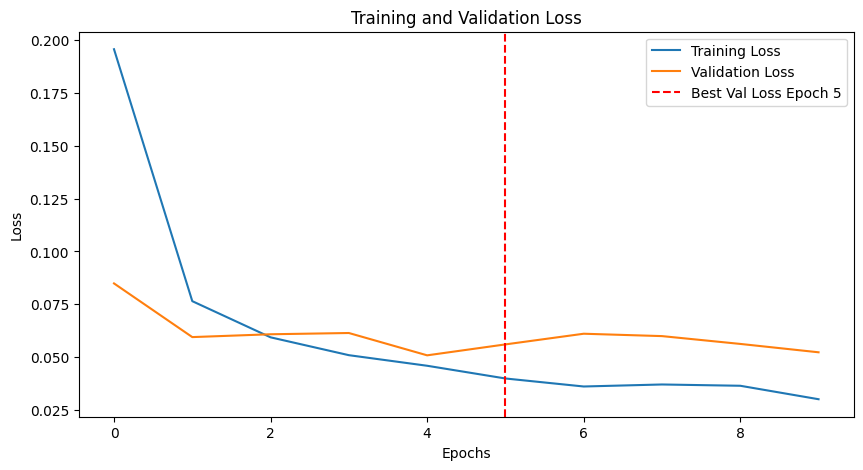

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# Find the epoch with the best validation loss
best_epoch = np.argmin(val_losses) + 1 # Add 1 because epochs are 1-indexed

# Add a vertical red line at the epoch with the best validation loss
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Val Loss Epoch {best_epoch}')
plt.legend()

plt.show()

Finally, load the model (if not freshly trained, but from checkpoint).

In [26]:
# Define the path where the best model was saved
path = Path(os.getcwd())
model_save_path = path / 'best_lenet.pth'

# Instantiate a new model with the same architecture
# Make sure you use the same model class that was trained
loaded_model = ClassicLeNet5()

# Load the saved state dictionary into the new model instance
# Make sure the model is on the correct device (CPU or GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
loaded_model.load_state_dict(torch.load(model_save_path, map_location=device))

# Move the model to the device
loaded_model = loaded_model.to(device)

# Set the model to evaluation mode
loaded_model.eval()

print(f"Model loaded successfully from {model_save_path}")
print(f"Model is on device: {next(loaded_model.parameters()).device}")

Model loaded successfully from /content/best_lenet.pth
Model is on device: cpu



**Task 1: Create visualizations of the embedding space with PCA and UMAP in FiftyOne**


For this we will need a baseline model that gives its embedding space. We will use the LeNet


Install fityone plugins.

In [27]:
!fiftyone plugins download \
    https://github.com/voxel51/fiftyone-plugins \
    --plugin-names @voxel51/evaluation


Copying plugin '@voxel51/evaluation' to '/root/fiftyone/__plugins__/@voxel51/evaluation'


In [28]:
!fiftyone plugins download https://github.com/jacobmarks/fiftyone-albumentations-plugin


Copying plugin '@jacobmarks/albumentations_augmentation' to '/root/fiftyone/__plugins__/@jacobmarks/albumentations_augmentation'


**Load ad visualize data using FortyOne**

Launch the App

We could use any model (even OpenAIs Clip), but to really find critical samples, it is necessary that our model has already great classificaiton abilities. Limiting the false detected samples to actually faulty samples.

For this, we will use your LeNet that already showed us good results.


- We get the embeddings via the compute_embeddings()




Function to compute all emebddings of the dataset using a pre-trained model

In [29]:
## Extract Embeddings from LeNet Model Using PyTorch Hooks

def extract_lenet_embeddings(model, dataloader, device, layer_name='fc1'):
    """
    Extract embeddings from a specified layer of the LeNet model using PyTorch hooks.

    Args:
        model: Trained LeNet model
        dataloader: PyTorch DataLoader
        device: Device to run inference on
        layer_name: Name of the layer to extract embeddings from
                   Options: 'conv3', 'fc1', or 'fc2'

    Returns:
        numpy array of embeddings
    """
    # Dictionary to store the embeddings
    embeddings_dict = {}

    def hook_fn(module, input, output):
        """Hook function to capture layer outputs"""
        # Flatten the output if it's from conv layers
        if len(output.shape) > 2:
            embeddings_dict['embeddings'] = output.view(output.size(0), -1).cpu().detach()
        else:
            embeddings_dict['embeddings'] = output.cpu().detach()

    # Register the hook on the specified layer
    layer_map = {
        'conv3': model.conv3,  # Shape: (batch_size, 120, 1, 1) -> flattened to (batch_size, 120)
        'fc1': model.fc1,     # Shape: (batch_size, 84) - most common choice
        'fc2': model.fc2      # Shape: (batch_size, 10) - final logits
    }

    if layer_name not in layer_map:
        raise ValueError(f"Invalid layer_name. Choose from: {list(layer_map.keys())}")

    target_layer = layer_map[layer_name]
    hook_handle = target_layer.register_forward_hook(hook_fn)

    # Set model to evaluation mode
    model.eval()

    all_embeddings = []

    print(f"Extracting embeddings from {layer_name} layer...")

    with torch.inference_mode():
        for images, _ in tqdm(dataloader, desc="Processing batches"):
            images = images.to(device)

            # Forward pass (hook will capture the embeddings)
            _ = model(images)

            # Store the captured embeddings
            batch_embeddings = embeddings_dict['embeddings'].numpy()
            all_embeddings.append(batch_embeddings)

    # Remove the hook to clean up
    hook_handle.remove()

    # Concatenate all embeddings
    final_embeddings = np.concatenate(all_embeddings, axis=0)

    print(f"Extracted embeddings shape: {final_embeddings.shape}")
    print(f"Embedding dimension: {final_embeddings.shape[1]}")

    return final_embeddings

**We like to run the model on the train_set/val_set to generate the logits and embeddings to curate the dataset later on. So we  will calculate and store all the metrics (UMAP/PCA, Similarity, Uniqueness, Representativeness, Hardness, Mistakeness) for both.**


In [89]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

def run_lenet_inference_with_embeddings(
    model,
    torch_dataset,
    device,
    batch_size=64,
    num_workers=4,
    embedding_layer_name="fc1",
):
    """
    Läuft einmal über einen Torch-Datensatz und liefert:
    - predictions: (N,)
    - logits:      (N, num_classes)
    - embeddings:  (N, embedding_dim)
    """

    dataloader = DataLoader(
        torch_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    model.eval()
    model.to(device)

    all_logits = []
    all_preds = []
    all_embeds = []

    # --- Forward-Hook auf die gewünschte Schicht (fc1) ---
    hook_activations = []

    def hook_fn(module, input, output):
        # output: Tensor (B, embedding_dim)
        hook_activations.append(output.detach().cpu())

    # Annahme: dein LeNet hat ein Attribut `fc1`
    handle = getattr(model, embedding_layer_name).register_forward_hook(hook_fn)

    with torch.inference_mode():
        for images, _ in dataloader:
            images = images.to(device)

            # Hook-Buffer leeren, damit wir nur aktuelle Batch haben
            hook_activations.clear()

            logits = model(images)              # Vorwärtslauf
            preds = torch.argmax(logits, dim=1)

            # Logits
            all_logits.append(logits.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            # Embeddings aus dem Hook
            # hook_activations ist eine Liste mit genau einem Tensor (für diesen Forward)
            embeds_batch = hook_activations[0]  # shape: (B, embedding_dim)
            all_embeds.append(embeds_batch.numpy())

    # Hook wieder entfernen
    handle.remove()

    # alles konkatenieren
    all_logits = np.concatenate(all_logits, axis=0)     # (N, C)
    all_embeds = np.concatenate(all_embeds, axis=0)     # (N, D)
    all_preds = np.array(all_preds)                     # (N,)

    return all_preds, all_logits, all_embeds


In [91]:

# Apply on test set

print("Running LeNet inference (logits + embeddings) on TEST set...")
test_preds, test_logits, test_embeds = run_lenet_inference_with_embeddings(
    model=loaded_model,
    torch_dataset=torch_test_set,
    device=device,
    batch_size=batch_size,
    num_workers=num_workers,
    embedding_layer_name="fc1",   # oder wie deine fc-Schicht heißt
)

print("Storing TEST predictions, logits and embeddings into FiftyOne dataset...")

for i, sample in enumerate(test_dataset):
    predicted_idx = int(test_preds[i])
    predicted_label = dataset_classes[predicted_idx]

    sample_logits = test_logits[i]      # shape: (num_classes,)
    sample_embed = test_embeds[i]       # shape: (embedding_dim,)

    # Softmax-Confidences
    confidences = F.softmax(torch.tensor(sample_logits), dim=0).numpy()
    predicted_confidence = float(confidences[predicted_idx])

    # Classification mit Logits
    classification = fo.Classification(
        label=predicted_label,
        confidence=predicted_confidence,
        logits=sample_logits.tolist(),
    )

    sample["lenet_test_classification"] = classification
    sample["lenet_test_embeddings"] = sample_embed.tolist()
    sample.save()

print("Done storing TEST logits + embeddings.")


Running LeNet inference (logits + embeddings) on TEST set...
Storing TEST predictions, logits and embeddings into FiftyOne dataset...
Done storing TEST logits + embeddings.


In [66]:
# Apply on train set
print("Running LeNet inference (logits + embeddings) on TRAIN set...")
train_preds, train_logits, train_embeds = run_lenet_inference_with_embeddings(
    model=loaded_model,
    torch_dataset=torch_train_set,
    device=device,
    batch_size=batch_size,
    num_workers=num_workers,
    embedding_layer_name="fc1",
)

print("Storing TRAIN predictions, logits and embeddings into FiftyOne dataset...")

for i, sample in enumerate(train_dataset):
    predicted_idx = int(train_preds[i])
    predicted_label = dataset_classes[predicted_idx]

    sample_logits = train_logits[i]
    sample_embed = train_embeds[i]

    confidences = F.softmax(torch.tensor(sample_logits), dim=0).numpy()
    predicted_confidence = float(confidences[predicted_idx])

    classification = fo.Classification(
        label=predicted_label,
        confidence=predicted_confidence,
        logits=sample_logits.tolist(),
    )

    sample["lenet_train_classification"] = classification
    sample["lenet_train_embeddings"] = sample_embed.tolist()
    sample.save()

print("Done storing TRAIN logits + embeddings.")


Running LeNet inference (logits + embeddings) on TRAIN set...
Storing TRAIN predictions, logits and embeddings into FiftyOne dataset...
Done storing TRAIN logits + embeddings.


**Use PCA and UMAP to visualize**
- We could use both train and test set, but for simplicity we will stick to the test set, to see how well the embedding space generalized to the test set. It will ofcourse also be faster, as the dataset is notable smaller (factor 5).

In [72]:
pca_visualization = fob.compute_visualization(test_dataset,
                                              method="pca",
                                              embeddings="lenet_test_embeddings",
                                              num_dims=2,
                                              brain_key="lenet_pca_test")

Computing embeddings...


INFO:fiftyone.brain.internal.core.utils:Computing embeddings...


 100% |█████████████| 10000/10000 [12.4m elapsed, 0s remaining, 16.4 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 10000/10000 [12.4m elapsed, 0s remaining, 16.4 samples/s]      


Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...


In [73]:
umap_visualization = fob.compute_visualization(test_dataset,
                                              method="umap",
                                              embeddings="lenet_test_embeddings",
                                              num_dims=2,
                                              brain_key="lenet_umap_test")

Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...


UMAP( verbose=True)
Fri Nov 21 11:04:57 2025 Construct fuzzy simplicial set
Fri Nov 21 11:04:57 2025 Finding Nearest Neighbors
Fri Nov 21 11:04:57 2025 Building RP forest with 10 trees
Fri Nov 21 11:04:58 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Fri Nov 21 11:05:00 2025 Finished Nearest Neighbor Search
Fri Nov 21 11:05:00 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Nov 21 11:05:19 2025 Finished embedding


In [75]:
print("Computing similarity index based on train LeNet embeddings...")

lenet_similarity_index = fob.compute_similarity(
    train_dataset,  # Using the training dataset
    embeddings="lenet_train_embeddings",  # Field containing the LeNet embeddings
    brain_key="lenet_cosine_similarity_index",  # Unique identifier for this similarity index
    backend="sklearn",  # Can also use "pinecone" for large datasets
    metric="cosine"  # Similarity metric
)

print(f"LeNet similarity index computed successfully!")

Computing similarity index based on train LeNet embeddings...


ValueError: Brain method run with key 'lenet_cosine_similarity_index' already exists

In [92]:
print("Computing similarity index based on testLeNet embeddings...")

lenet_similarity_index = fob.compute_similarity(
    test_dataset,  # Using the training dataset
    embeddings="lenet_tes_embeddingst",  # Field containing the LeNet embeddings
    brain_key="lenet_cosine_similarity_index",  # Unique identifier for this similarity index
    backend="sklearn",  # Can also use "pinecone" for large datasets
    metric="cosine"  # Similarity metric
)

print(f"LeNet similarity index computed successfully!")

Computing similarity index based on testLeNet embeddings...


ValueError: Brain method run with key 'lenet_cosine_similarity_index' already exists

In [78]:
session.refresh()
print(session.url)

https://5151-m-s-13ibs32b7int5-c.us-west1-0.prod.colab.dev?polling=true


# **Search of questionable elments:**

For this we will search through both train and test set, use logits and embeddings metrics to filter out small subsets of the data that have high probability of being questionabe.


*   First, get missclassified images










In [93]:
from fiftyone import ViewField as F

misclassified_view = train_dataset.match(
    F("lenet_train_classification.label") != F("ground_truth.label")
)

print(f"Misclassified samples: {len(misclassified_view)} samples")

Misclassified samples: 525 samples


In [94]:
misclassified_view = test_dataset.match(
    F("lenet_test_classification.label") != F("ground_truth.label")
)
print(f"Misclassified samples: {len(misclassified_view)} samples")

Misclassified samples: 151 samples




*   Now calculate metrics and top 1% quantile to reduce search space



In [95]:
#Hardness is a measure computed based on model prediction output (through
#logits) that summarizes a measure of the uncertainty the model had with the
#sample. This makes hardness quantitative and can be used to detect things
#like hard samples and annotation errors
fob.compute_hardness(train_dataset,
                     label_field='lenet_train_classification',
                     )
# Evaluate sample mistakenness (how likely the sample is mislabeled)
# Samples with high mistakenness often have conflicting model output and ground truth
fob.compute_mistakenness(train_dataset,
                         pred_field="lenet_train_classification",
                         label_field="ground_truth")



Computing hardness...


INFO:fiftyone.brain.internal.core.hardness:Computing hardness...


 100% |█████████████| 51000/51000 [3.1m elapsed, 0s remaining, 252.9 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 51000/51000 [3.1m elapsed, 0s remaining, 252.9 samples/s]      


Hardness computation complete


...

INFO:fiftyone.brain.internal.core.mistakenness:Computing mistakenness...


 100% |█████████████| 51000/51000 [2.4m elapsed, 0s remaining, 388.8 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 51000/51000 [2.4m elapsed, 0s remaining, 388.8 samples/s]      


Mistakenness computation complete


INFO:fiftyone.brain.internal.core.mistakenness:Mistakenness computation complete


In [97]:
fob.compute_hardness(test_dataset,
                     label_field='lenet_test_classification',
                     )

fob.compute_mistakenness(test_dataset,
                         pred_field="lenet_test_classification",
                         label_field="ground_truth")

Computing hardness...


INFO:fiftyone.brain.internal.core.hardness:Computing hardness...


 100% |█████████████| 10000/10000 [33.5s elapsed, 0s remaining, 321.4 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 10000/10000 [33.5s elapsed, 0s remaining, 321.4 samples/s]      


Hardness computation complete


...

INFO:fiftyone.brain.internal.core.mistakenness:Computing mistakenness...


 100% |█████████████| 10000/10000 [28.4s elapsed, 0s remaining, 421.5 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 10000/10000 [28.4s elapsed, 0s remaining, 421.5 samples/s]      


Mistakenness computation complete


INFO:fiftyone.brain.internal.core.mistakenness:Mistakenness computation complete


In [102]:
# Compute quantiles of mistakenness
mistakenness_quantiles = train_dataset.quantiles(
    "mistakenness",
    [0.9, 0.95, 0.99]
)

print("\nMistakenness quantiles for train_dataset:")
print(mistakenness_quantiles)

suspicious_train_samples_view = train_dataset.match(
                             F("mistakenness") > mistakenness_quantiles[-1]
                             ).sort_by("mistakenness", reverse=True)



Mistakenness quantiles for train_dataset:
[0.0064293742179870605, 0.025132298469543457, 0.694474384188652]


In [103]:
# Compute quantiles of mistakenness
mistakenness_quantiles = test_dataset.quantiles(
    "mistakenness",
    [0.9, 0.95, 0.99]
)

print("\nMistakenness quantiles for test_dataset:")
print(mistakenness_quantiles)

suspicious_test_samples_view = test_dataset.match(
                             F("mistakenness") > mistakenness_quantiles[-1]
                             ).sort_by("mistakenness", reverse=True)




Mistakenness quantiles for test_dataset:
[0.006535589694976807, 0.03352171182632446, 0.8257096707820892]


*  Now the same for hardness


In [104]:
# Compute quantiles of hardness for the validation set
hardness_train_quantiles = train_dataset.quantiles(
    "hardness",
    [0.9, 0.95, 0.99]
)

print("\nHardness quantiles for train:")
print(hardness_train_quantiles)

# Create a view of samples with high hardness in the test set
hard_train_samples_view = train_dataset.match(
                         F("hardness") > hardness_train_quantiles[-1]
                         ).sort_by("hardness", reverse=True)

# Set the session v



Hardness quantiles for train:
[0.07586917508100541, 0.2183953068425988, 0.7393309783189074]


In [105]:
# Compute quantiles of hardness for the validation set
hardness_test_quantiles = test_dataset.quantiles(
    "hardness",
    [0.9, 0.95, 0.99]
)

print("\nHardness quantiles for validation_dataset:")
print(hardness_test_quantiles)

hard_test_samples_view = test_dataset.match(
                         F("hardness") > hardness_train_quantiles[-1]
                         ).sort_by("hardness", reverse=True)




Hardness quantiles for validation_dataset:
[0.0757493351944078, 0.2555402534755196, 0.7831985640169773]




*   Finally, do the same for Uniqueness and Representativeness



In [106]:
## Compute Uniqueness and Representativeness for LeNet Embeddings

print("Computing uniqueness scores based on train LeNet embeddings...")
fob.compute_uniqueness(train_dataset, embeddings='lenet_train_embeddings')

print("Computing representativeness scores based on train LeNet embeddings...")
fob.compute_representativeness(train_dataset, embeddings='lenet_train_embeddings')

print("Uniqueness and representativeness computation complete.")

Computing uniqueness scores based on train LeNet embeddings...


INFO:fiftyone.core.models:Downloading model from Google Drive ID '1SIO9XreK0w1ja4EuhBWcR10CnWxCOsom'...


 100% |████|  100.6Mb/100.6Mb [192.7ms elapsed, 0s remaining, 521.9Mb/s]      


INFO:eta.core.utils: 100% |████|  100.6Mb/100.6Mb [192.7ms elapsed, 0s remaining, 521.9Mb/s]      


Computing embeddings...


...

Computing clusters for 51000 embeddings; this may take awhile...


INFO:fiftyone.brain.internal.core.representativeness:Computing clusters for 51000 embeddings; this may take awhile...


Representativeness computation complete


INFO:fiftyone.brain.internal.core.representativeness:Representativeness computation complete


Uniqueness and representativeness computation complete.


In [107]:
print("Computing uniqueness scores based on test test LeNet embeddings...")
fob.compute_uniqueness(test_dataset, embeddings='lenet_test_embeddings')

print("Computing representativeness scores based on test LeNet embeddings...")
fob.compute_representativeness(test_dataset, embeddings='lenet_test_embeddings')

Computing uniqueness scores based on test test LeNet embeddings...
Computing uniqueness...


INFO:fiftyone.brain.internal.core.uniqueness:Computing uniqueness...


Uniqueness computation complete


INFO:fiftyone.brain.internal.core.uniqueness:Uniqueness computation complete


Computing representativeness scores based on test LeNet embeddings...
Computing representativeness...


INFO:fiftyone.brain.internal.core.representativeness:Computing representativeness...


Computing clusters for 10000 embeddings; this may take awhile...


INFO:fiftyone.brain.internal.core.representativeness:Computing clusters for 10000 embeddings; this may take awhile...


Representativeness computation complete


INFO:fiftyone.brain.internal.core.representativeness:Representativeness computation complete


# **Create Vis of Quantiles, use them to filter out suspicious elements**






# **We will start with the train set:**

In [130]:
filenames_of_samples_to_exclude_train = set([])

In [166]:
# Get quantiles for uniqueness based on train LeNet embeddings

quantiles_of_interest = [0.5, 0.75, 0.95, 0.99, 0.999]
uniqueness_quantiles = train_dataset.quantiles("uniqueness", quantiles_of_interest)
quantile_labels = [f"{label*100:.1f}% " for label in quantiles_of_interest]
print('Uniqueness quantiles')
{label: value for label, value in zip(quantile_labels, uniqueness_quantiles)}

quantiles_of_interest = [0.5, 0.75, 0.95, 0.99, 0.999]
representativeness_quantiles = train_dataset.quantiles("representativeness", quantiles_of_interest)
print('Representativeness quantiles')
{label: value for label, value in zip(quantile_labels, representativeness_quantiles)}

Uniqueness quantiles
Representativeness quantiles


{'50.0% ': 0.7356803433264646,
 '75.0% ': 0.7825928794403745,
 '95.0% ': 0.8534300673117232,
 '99.0% ': 0.9060767313996413,
 '99.9% ': 0.9740151414853403}

In [167]:
# Most unique samples (top 0.1% - these are often edge cases or outliers)
most_unique_samples_view = train_dataset.match(
                             F("uniqueness") > uniqueness_quantiles[-1]
                             ).sort_by("uniqueness", reverse=True)

print(f"Most unique samples: {len(most_unique_samples_view)} samples")

# Most representative samples (top 0.1% - these exemplify their clusters well)
# (Just to look at them, but not really used to exclude samples)
most_representative_samples_view = train_dataset.match(
    F("representativeness") > representativeness_quantiles[-1]
    ).sort_by("representativeness", reverse=True)

print(f"Most representative samples: {len(most_representative_samples_view)} samples")


Most unique samples: 51 samples
Most representative samples: 51 samples


In [168]:
# Get the sample with the highest uniqueness score
most_unique_sample = most_unique_samples_view.first()

print(f"""Most unique sample ID: {most_unique_sample.id}
Uniqueness score: {most_unique_sample.uniqueness:.4f}
Ground truth label: {most_unique_sample.ground_truth.label}""")

# Find images most similar to the most unique one using the LeNet similarity index
# We want the most similar samples, so reverse=False
similar_to_unique_view = train_dataset.sort_by_similarity(
    most_unique_sample.id,
    brain_key="lenet_cosine_similarity_index", # Use the LeNet index
    k=20, # Get the top 20 similar samples (including the unique one itself)
    reverse=False
)

print(f"Found {len(similar_to_unique_view)} samples most similar to the most unique one.")

# Visualize the samples similar to the most unique one
session.view = similar_to_unique_view
session.refresh()
print(session.url)


Most unique sample ID: 69203592b974c0c460b3e705
Uniqueness score: 1.0000
Ground truth label: 7 - seven
Found 20 samples most similar to the most unique one.
https://5151-m-s-13ibs32b7int5-c.us-west1-0.prod.colab.dev?polling=true


In [139]:

filenames_of_samples_to_exclude_train.update(["/root/fiftyone/mnist/train/data/032739.jpg"])


In [169]:
## Visualize most unique images
session.view = most_unique_samples_view
session.refresh()
print(f"FiftyOne App URL: {session.url}")

FiftyOne App URL: https://5151-m-s-13ibs32b7int5-c.us-west1-0.prod.colab.dev?polling=true


In [138]:
filenames_of_samples_to_exclude_train.update([
    "/root/fiftyone/mnist/train/data/048882.jpg",
    "/root/fiftyone/mnist/train/data/035063.jpg",
    "/root/fiftyone/mnist/train/data/021991.jpg",
    "/root/fiftyone/mnist/train/data/034522.jpg",
    "/root/fiftyone/mnist/train/data/019869.jpg",
    "/root/fiftyone/mnist/train/data/049684.jpg",
    "/root/fiftyone/mnist/train/data/037428.jpg",
    "/root/fiftyone/mnist/train/data/026851.jpg",
    "/root/fiftyone/mnist/train/data/026835.jpg"])


In [112]:
# ## Visualize most representative images
# session.view = most_representative_samples_view
# session.refresh()
# print(f"FiftyOne App URL: {session.url}")

FiftyOne App URL: https://5151-m-s-13ibs32b7int5-c.us-west1-0.prod.colab.dev?polling=true


*   Now filter out most questionable elements. To reduce the search space, we will use for this mainly the Union of mistakness and hardness.





In [114]:
# Identify samples in the top 0.1 percentile of mistakenness (likely annotation errors)mistakenness_99th_percentile = train_dataset.quantiles("mistakenness", [0.99])[0]
mistakenness_99th_percentile = train_dataset.quantiles("mistakenness", [0.999])[0]
highly_mistaken_view = train_dataset.match(F("mistakenness") > mistakenness_99th_percentile)

# Identify samples in the top 1 percentile of hardness (likely genuinely hard samples)
hardness_99th_percentile = train_dataset.quantiles("hardness", [0.999])[0]
highly_hard_view = train_dataset.match(F("hardness") > hardness_99th_percentile)

print(f"Number of highly mistaken samples (top 1%): {len(highly_mistaken_view)}")
print(f"Number of highly hard samples (top 1%): {len(highly_hard_view)}")

# Get the IDs of samples that are highly mistaken or highly hard
highly_mistaken_ids = set(highly_mistaken_view.values("id"))
highly_hard_ids = set(highly_hard_view.values("id"))

# Combine the sets of IDs that are hard
difficult_samples = highly_mistaken_ids.union(highly_hard_ids)

print(f"Total number of difficult samples (union of highly mistaken and highly hard): {len(difficult_samples)}")



Number of highly mistaken samples (top 1%): 51
Number of highly hard samples (top 1%): 51
Total number of difficult samples (union of highly mistaken and highly hard): 102


In [115]:
mislabeled_train_images_view = \
train_dataset.match(
    F("lenet_train_classification.label")!= F("ground_truth.label"))

In [116]:
# Get the IDs of the misclassified samples
misclassified_sample_ids = set(mislabeled_train_images_view.values("id"))

print(f"Total number of misclassified samples in the training set: {len(misclassified_sample_ids)}")

# Find the intersection of difficult samples and misclassified samples
intersection_difficult_misclassified_ids = difficult_samples.intersection(misclassified_sample_ids)

print(f"Number of samples that are both difficult and misclassified: {len(intersection_difficult_misclassified_ids)}")

# Create a FiftyOne view containing only these intersection samples
intersection_difficult_misclassified_view = train_dataset.select(
    list(intersection_difficult_misclassified_ids)
    ).sort_by('hardness',
              reverse=True)


print(f"Created a FiftyOne view for the intersection samples with {len(intersection_difficult_misclassified_view)} samples.")


# Inspect the samples in ids_to_remove, we can decide whether
# whether we augment them or exclude them from the fine-tuning data
session.view = intersection_difficult_misclassified_view
session.refresh()
print(f"\nFiftyOne App URL: {session.url}")

Total number of misclassified samples in the training set: 525
Number of samples that are both difficult and misclassified: 80
Created a FiftyOne view for the intersection samples with 80 samples.

FiftyOne App URL: https://5151-m-s-13ibs32b7int5-c.us-west1-0.prod.colab.dev?polling=true


In [137]:
filenames_of_samples_to_exclude_train.update([
    "/root/fiftyone/mnist/train/data/010206.jpg",
    "/root/fiftyone/mnist/train/data/053737.jpg",
    "/root/fiftyone/mnist/train/data/042688.jpg",
    "/root/fiftyone/mnist/train/data/056398.jpg",
    "/root/fiftyone/mnist/train/data/042688.jpg",
    "/root/fiftyone/mnist/train/data/032245.jpg",
    "/root/fiftyone/mnist/train/data/054783.jpg",
    "/root/fiftyone/mnist/train/data/021602.jpg",
    "/root/fiftyone/mnist/train/data/017740.jpg",
    "/root/fiftyone/mnist/train/data/005014.jpg",
    "/root/fiftyone/mnist/train/data/036349.jpg",
    "/root/fiftyone/mnist/train/data/032574.jpg",
    "/root/fiftyone/mnist/train/data/016677.jpg",
    "/root/fiftyone/mnist/train/data/013260.jpg",
    "/root/fiftyone/mnist/train/data/057883.jpg",
    "/root/fiftyone/mnist/train/data/028492.jpg",
    "/root/fiftyone/mnist/train/data/000173.jpg",
    "/root/fiftyone/mnist/train/data/051945.jpg",
    "/root/fiftyone/mnist/train/data/036935.jpg",
    "/root/fiftyone/mnist/train/data/040705.jpg",
    "/root/fiftyone/mnist/train/data/012184.jpg",
    "/root/fiftyone/mnist/train/data/030605.jpg",
    "/root/fiftyone/mnist/train/data/033507.jpg",
    "/root/fiftyone/mnist/train/data/004477.jpg",
    "/root/fiftyone/mnist/train/data/057663.jpg",
    "/root/fiftyone/mnist/train/data/053639.jpg",
    "/root/fiftyone/mnist/train/data/026561.jpg",
    "/root/fiftyone/mnist/train/data/045353.jpg",
    "/root/fiftyone/mnist/train/data/040387.jpg",
    "/root/fiftyone/mnist/train/data/004029.jpg",
    "/root/fiftyone/mnist/train/data/043455.jpg",
    "/root/fiftyone/mnist/train/data/034405.jpg",
    "/root/fiftyone/mnist/train/data/059916.jpg",
    "/root/fiftyone/mnist/train/data/035617.jpg",
    "/root/fiftyone/mnist/train/data/000903.jpg",
    "/root/fiftyone/mnist/train/data/027523.jpg"])



**Exclude files**



In [140]:
# Use match() to filter by filepath
samples_to_exclude_view = train_dataset.match(
    fo.ViewField("filepath").is_in(filenames_of_samples_to_exclude_train)
)
print('Samples to exclude from new training runs')
session.view = samples_to_exclude_view
session.refresh()
print(session.url)

Samples to exclude from new training runs
https://5151-m-s-13ibs32b7int5-c.us-west1-0.prod.colab.dev?polling=true


In [141]:
# get the ids from samples_to_exclude_view
ids_of_samples_to_exclude_train = samples_to_exclude_view.values("id")
ids_of_samples_to_exclude_train

['6920358ab974c0c460b39a74',
 '6920358bb974c0c460b39ff1',
 '6920358cb974c0c460b3b7bb',
 '6920358db974c0c460b3bc17',
 '6920358db974c0c460b3bf77',
 '69203593b974c0c460b3e89c',
 '69203594b974c0c460b3f7c3',
 '69203595b974c0c460b400f5',
 '69203598b974c0c460b41b42',
 '69203598b974c0c460b42319',
 '6920359ab974c0c460b43391',
 '6920359bb974c0c460b44194',
 '6920359bb974c0c460b44449',
 '6920359eb974c0c460b467d2',
 '6920359fb974c0c460b46aa0',
 '6920359fb974c0c460b46ab0',
 '692035a0b974c0c460b46fcc',
 '692035a0b974c0c460b47701',
 '692035a2b974c0c460b48804',
 '692035a4b974c0c460b4942f',
 '692035a4b974c0c460b497d5',
 '692035a4b974c0c460b4987a',
 '692035a5b974c0c460b49e16',
 '692035a5b974c0c460b4a575',
 '692035a5b974c0c460b4a739',
 '692035a6b974c0c460b4aaa0',
 '692035a6b974c0c460b4af40',
 '692035a6b974c0c460b4b4ba',
 '692035a7b974c0c460b4b96a',
 '692035a8b974c0c460b4bdd8',
 '692035a9b974c0c460b4d40f',
 '692035aab974c0c460b4d6a3',
 '692035abb974c0c460b4e602',
 '692035acb974c0c460b4ec21',
 '692035adb974

# **Now we will look at the test set and do the same**



In [170]:
filenames_of_samples_to_exclude_test = set([])


In [174]:
# Get quantiles for uniqueness based on train LeNet embeddings

quantiles_of_interest = [0.5, 0.75, 0.95, 0.99, 0.999]
uniqueness_quantiles = test_dataset.quantiles("uniqueness", quantiles_of_interest)
quantile_labels = [f"{label*100:.1f}% " for label in quantiles_of_interest]
print('Uniqueness quantiles')
{label: value for label, value in zip(quantile_labels, uniqueness_quantiles)}

quantiles_of_interest = [0.5, 0.75, 0.95, 0.99, 0.999]
representativeness_quantiles = test_dataset.quantiles("representativeness", quantiles_of_interest)
print('Representativeness quantiles')
{label: value for label, value in zip(quantile_labels, representativeness_quantiles)}

Uniqueness quantiles
Representativeness quantiles


{'50.0% ': 0.43479871938472175,
 '75.0% ': 0.5380336703788948,
 '95.0% ': 0.7411427570261184,
 '99.0% ': 0.8977633694769357,
 '99.9% ': 1.0}

In [176]:
# Most unique samples (top 0.1% - these are often edge cases or outliers)
most_unique_samples_view = test_dataset.match(
                             F("uniqueness") > uniqueness_quantiles[-1]
                             ).sort_by("uniqueness", reverse=True)

print(f"Most unique samples: {len(most_unique_samples_view)} samples")

# Most representative samples (top 0.1% - these exemplify their clusters well)
most_representative_samples_view = test_dataset.match(
    F("representativeness") > representativeness_quantiles[-1]
    ).sort_by("representativeness", reverse=True)

print(f"Most representative samples: {len(most_representative_samples_view)} samples")


Most unique samples: 10 samples
Most representative samples: 0 samples


In [177]:
# Get the sample with the highest uniqueness score
most_unique_sample = most_unique_samples_view.first()

print(f"""Most unique sample ID: {most_unique_sample.id}
Uniqueness score: {most_unique_sample.uniqueness:.4f}
Ground truth label: {most_unique_sample.ground_truth.label}""")

# Find images most similar to the most unique one using the LeNet similarity index
# We want the most similar samples, so reverse=False
similar_to_unique_view = test_dataset.sort_by_similarity(
    most_unique_sample.id,
    brain_key="lenet_cosine_similarity_index", # Use the LeNet index
    k=20, # Get the top 20 similar samples (including the unique one itself)
    reverse=False
)

print(f"Found {len(similar_to_unique_view)} samples most similar to the most unique one.")

# Visualize the samples similar to the most unique one
session.view = similar_to_unique_view
session.refresh()
print(session.url)


Most unique sample ID: 692035e2b974c0c460b5b1e7
Uniqueness score: 1.0000
Ground truth label: 2 - two
Found 20 samples most similar to the most unique one.
https://5151-m-s-13ibs32b7int5-c.us-west1-0.prod.colab.dev?polling=true


In [155]:
filenames_of_samples_to_exclude_test.update([
    "/root/fiftyone/mnist/test/data/009635.jpg",
    "/root/fiftyone/mnist/test/data/009717.jpg",
    "/root/fiftyone/mnist/test/data/006561.jpg",
    "/root/fiftyone/mnist/test/data/003812.jpg",
    "/root/fiftyone/mnist/test/data/009717.jpg",
    "/root/fiftyone/mnist/test/data/003812.jpg",
    "/root/fiftyone/mnist/test/data/006561.jpg",
    "/root/fiftyone/mnist/test/data/009635.jpg"
])

In [178]:
mistakenness_99th_percentile = test_dataset.quantiles("mistakenness", [0.999])[0]
highly_mistaken_view = test_dataset.match(F("mistakenness") > mistakenness_99th_percentile)

# Identify samples in the top 1 percentile of hardness (likely genuinely hard samples)
hardness_99th_percentile = test_dataset.quantiles("hardness", [0.999])[0]
highly_hard_view = test_dataset.match(F("hardness") > hardness_99th_percentile)

print(f"Number of highly mistaken samples (top 1%): {len(highly_mistaken_view)}")
print(f"Number of highly hard samples (top 1%): {len(highly_hard_view)}")

# Get the IDs of samples that are highly mistaken or highly hard
highly_mistaken_ids = set(highly_mistaken_view.values("id"))
highly_hard_ids = set(highly_hard_view.values("id"))

# Combine the sets of IDs that are hard
difficult_samples = highly_mistaken_ids.union(highly_hard_ids)

print(f"Total number of difficult samples (union of highly mistaken and highly hard): {len(difficult_samples)}")



Number of highly mistaken samples (top 1%): 10
Number of highly hard samples (top 1%): 10
Total number of difficult samples (union of highly mistaken and highly hard): 20


In [179]:
mislabeled_test_images_view = \
test_dataset.match(
    F("lenet_test_classification.label")!= F("ground_truth.label"))

In [180]:
# Get the IDs of the misclassified samples
misclassified_sample_ids = set(mislabeled_test_images_view.values("id"))

print(f"Total number of misclassified samples in the test set: {len(misclassified_sample_ids)}")

# Find the intersection of difficult samples and misclassified samples
intersection_difficult_misclassified_ids = difficult_samples.intersection(misclassified_sample_ids)

print(f"Number of samples that are both difficult and misclassified: {len(intersection_difficult_misclassified_ids)}")

# Create a FiftyOne view containing only these intersection samples
intersection_difficult_misclassified_view = test_dataset.select(
    list(intersection_difficult_misclassified_ids)
    ).sort_by('hardness',
              reverse=True)


print(f"Created a FiftyOne view for the intersection samples with {len(intersection_difficult_misclassified_view)} samples.")


# Inspect the samples in ids_to_remove, we can decide whether
# whether we augment them or exclude them from the fine-tuning data
session.view = intersection_difficult_misclassified_view
session.refresh()
print(f"\nFiftyOne App URL: {session.url}")

Total number of misclassified samples in the test set: 151
Number of samples that are both difficult and misclassified: 16
Created a FiftyOne view for the intersection samples with 16 samples.

FiftyOne App URL: https://5151-m-s-13ibs32b7int5-c.us-west1-0.prod.colab.dev?polling=true


In [181]:
filenames_of_samples_to_exclude_test.update([
    "/root/fiftyone/mnist/test/data/002267.jpg",
    "/root/fiftyone/mnist/test/data/003559.jpg",
    "/root/fiftyone/mnist/test/data/002294.jpg",
    "/root/fiftyone/mnist/test/data/002655.jpg",
    "/root/fiftyone/mnist/test/data/000583.jpg",
    "/root/fiftyone/mnist/test/data/009730.jpg",
    "/root/fiftyone/mnist/test/data/009680.jpg",
    "/root/fiftyone/mnist/test/data/004881.jpg",
])

# Optional, investigation using model confidence

In [ ]:
# # Calculate the 1th percentile (lowest percentile) of confidence scores for lenet_train_classification
# confidence_quantiles = train_dataset.quantiles("lenet_train_classification.confidence", [0.01])
# q10_confidence = confidence_quantiles[0]

# print(f"The 1th percentile of confidence is: {q10_confidence:.4f}")

# # Create a view of samples that were correctly classified AND have confidence <= 1th percentile
# low_confidence_correct_view = train_dataset.match(
#     (F("lenet_train_classification.label") == F("ground_truth.label")) &
#     (F("lenet_train_classification.confidence") <= q10_confidence)
# ).sort_by("lenet_train_classification.confidence")

# print(f"\nNumber of correctly classified samples with confidence <= {q10_confidence:.4f}: {len(low_confidence_correct_view)}")

# # We can launch the FiftyOne App to visualize this view
# session.view = low_confidence_correct_view
# session.refresh()
# print(session.url)

# Now we define Augmentations to expend our dataset later on

In [182]:
mnist_augmentations_1 = A.Compose([

    A.Affine(
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
        scale=(0.9, 1.1),
        rotate=(-5, 5),
        p=0.8
    ),

    A.ElasticTransform(
        alpha=20,
        sigma=5,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.6
    ),

    A.Perspective(scale=(0.01, 0.03), p=0.2),

    A.GridDistortion(num_steps=2, distort_limit=0.05, p=0.2),

])

In [183]:
# Define second set of augmentations
mnist_augmentations_2 = A.Compose([

    # Equalize the image histogram (can help with contrast variations)
    A.Equalize(p=0.3),

    # Affine with shear (simulates slanted handwriting)
    A.Affine(
        shear=(-5, 5),  # Add shear
        translate_percent={"x": (-0.03, 0.03), "y": (-0.03, 0.03)}, # Smaller translation
        scale=(0.98, 1.02), # Smaller scaling
        rotate=(-2, 2), # Smaller rotation
        border_mode=cv2.BORDER_CONSTANT,
        p=0.9
    ),

    # Mild perspective transformations
    A.Perspective(scale=(0.01, 0.03), p=0.2),

    # Mild grid distortion
    A.GridDistortion(num_steps=2, distort_limit=0.05, p=0.2),
])


In [184]:
# Define a third set of augmentations for MNIST
mnist_augmentations_3 = A.Compose([
    # Use Affine transform for shifting, scaling, and rotating
    A.Affine(
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},  # ±10% translation
        scale=(0.95, 1.15),     # ±15% scaling
        rotate=(-7, 7),         # ±7° rotation
        p=0.8
    ),

    # Elastic deformation with different parameters
    A.ElasticTransform(
        alpha=15,
        sigma=4,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.4
    ),

    # Coarse Dropout (simulates occlusions or pen lifts)
    A.CoarseDropout(
        p=0.3
    ),
])



In [185]:

# mix idk with normal to generate more idks
mnist_augmentations_4 = transforms.Compose([
    transforms.RandomApply([
        transforms.GaussianBlur(3),
        transforms.RandomErasing(p=0.7, scale=(0.05, 0.2)),
    ], p=0.7),
])


*   Add Dynamic Augmentation




In [186]:
class AugmentedMNISTDataset(Dataset):
    """
    PyTorch dataset that applies augmentations to misclassified MNIST samples.
    Each sample can be augmented multiple times to create more training data.
    """

    def __init__(self, fiftyone_view,
                 label_map,
                 base_transforms,
                 augmentations=None,
                 augment_factor=5):
        """
        Args:
            fiftyone_view: FiftyOne view of misclassified samples
            label_map: Mapping from string labels to indices
            base_transforms: Base PyTorch transforms (normalization, etc.)
            augmentations: Albumentations transform pipeline
            augment_factor: How many augmented versions to create per sample
        """
        self.image_paths = fiftyone_view.values("filepath")
        self.str_labels = fiftyone_view.values("ground_truth.label")
        self.label_map = label_map
        self.base_transforms = base_transforms
        self.augmentations = augmentations
        self.augment_factor = augment_factor

        print(f"AugmentedMNISTDataset: {len(self.image_paths)} base samples")
        print(f"With augmentation factor {augment_factor}: {len(self)} total samples")

    def __len__(self):
        return len(self.image_paths) * (self.augment_factor + 1)  # +1 for original

    def __getitem__(self, idx):
        # Determine which base sample and whether to augment
        base_idx = idx // (self.augment_factor + 1)
        aug_idx = idx % (self.augment_factor + 1)

        # Load image
        image_path = self.image_paths[base_idx]
        image = Image.open(image_path).convert('L')

        # Convert to numpy for albumentations
        image_np = np.array(image, dtype=np.uint8)

        # Apply augmentation if not the first version (original)
        if aug_idx > 0 and self.augmentations is not None:
            augmented = self.augmentations(image=image_np)
            image_np = augmented['image']

        # Convert back to PIL for PyTorch transforms
        image = Image.fromarray(image_np).convert("L")

        # Apply base transforms (normalization, tensor conversion)
        if self.base_transforms:
            image = self.base_transforms(image)

        # Get label
        label_str = self.str_labels[base_idx]
        label_idx = self.label_map.get(label_str, -1)

        return image, torch.tensor(label_idx, dtype=torch.long)



In [61]:
dataset_name = "digit-samples-to-augment"

if dataset_name in fo.list_datasets():
    print(f"Dataset '{dataset_name}' already exists. Deleting it.")
    fo.delete_dataset(dataset_name)

# Always create a new dataset after deleting or if it didn't exist
dataset_to_augment = fo.Dataset(dataset_name)

for sample in mislabeled_train_images_view:
    dataset_to_augment.add_sample(sample)

for sample in most_unique_samples_view:
    dataset_to_augment.add_sample(sample)

for sample in most_representative_samples_view:
    dataset_to_augment.add_sample(sample)

for sample in low_confidence_correct_view:
    dataset_to_augment.add_sample(sample)

dataset_to_augment.save()

ValueError: Failed to load sample from the database. This is likely due to an invalid stage in the DatasetView

In [ ]:
# Filter out excluded samples
dataset_to_augment = dataset_to_augment.exclude(ids_of_samples_to_exclude).clone()

In [ ]:
torch_augmented_dataset = AugmentedMNISTDataset(
    dataset_to_augment,
    label_map=label_map,
    base_transforms=image_transforms,
    augmentations=mnist_augmentations_1, # We can also try mnist_augmentations_2 or mnist_augmentations_3
    augment_factor=9  # Create this number of augmented versions per input sample
)

print(f"Original misclassified samples: {len(mislabeled_train_images_view)}")
print(f'')
print(f"Total augmented dataset size: {len(torch_augmented_dataset)}")



In [ ]:
# Combine the original dataset with its augmentation
combined_dataset = ConcatDataset([new_torch_train_set, torch_augmented_dataset])
print(f"Combined dataset size: {len(combined_dataset)}")

In [ ]:
# Create new DataLoader for combined dataset
combined_train_loader = create_deterministic_training_dataloader(
    combined_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)


print(f"Combined DataLoader has {len(combined_train_loader)} batches.")


Supervise Augmentation

In [ ]:
# Create a small dataset with original and augmented versions for visualization
def create_augmentation_samples(view, augmentations, num_samples=50):
    """Create FiftyOne samples showing original and augmented versions"""

    dataset_name = "augmented_images_training_set"

    if dataset_name in fo.list_datasets():
        aug_viz_dataset = fo.load_dataset(dataset_name)
    else:
        aug_viz_dataset = fo.Dataset(dataset_name)

    sample_paths = view.values("filepath")[:num_samples]
    sample_labels = view.values("ground_truth.label")[:num_samples]

    for i, (path, label) in enumerate(zip(sample_paths, sample_labels)):
        # Load original image
        original_image = Image.open(path).convert('L')
        original_np = np.array(original_image)

        # Create sample for original image
        original_sample = fo.Sample(filepath=path)
        original_sample.tags = ["original"]
        original_sample["ground_truth"] = fo.Classification(label=label)
        original_sample["augmentation_type"] = "original"
        aug_viz_dataset.add_sample(original_sample)

        # Create 3 augmented versions
        for aug_idx in range(3):
            # Apply augmentation
            augmented = augmentations(image=original_np)['image']

            # Save augmented image temporarily
            aug_image = Image.fromarray(augmented).convert("L")
            temp_path = f"/tmp/aug_{i}_{aug_idx}.png"
            aug_image.save(temp_path)

            # Create FiftyOne sample for augmented image
            aug_sample = fo.Sample(filepath=temp_path)
            aug_sample.tags = ["augmented"]
            aug_sample["ground_truth"] = fo.Classification(label=label)
            aug_sample["augmentation_type"] = f"augmented_{aug_idx + 1}"
            aug_sample["original_sample_id"] = str(i)

            aug_viz_dataset.add_sample(aug_sample)

    return aug_viz_dataset

print("Creating augmentation visualization dataset...")

# Create the visualization dataset
aug_viz_dataset = create_augmentation_samples(
    dataset_to_augment,
    mnist_augmentations_1,
    num_samples=50
)

print(f"Created visualization dataset with {len(aug_viz_dataset)} samples")
print(f"Original samples: {len(aug_viz_dataset.match_tags('original'))}")
print(f"Augmented samples: {len(aug_viz_dataset.match_tags('augmented'))}")

# Launch FiftyOne App to visualize the augmentations
session.view = aug_viz_dataset.view()

print(f"\nAugmentation Visualization URL: {session.url}")

In [ ]:
# Create views for easy comparison
original_view = aug_viz_dataset.match_tags("original")
augmented_view = aug_viz_dataset.match_tags("augmented")

print(f"\nTo compare:")
print(f"- View original samples: session.view = original_view")
print(f"- View augmented samples: session.view = augmented_view")
print(f"- Group by original sample: Use 'original_sample_id' field to group related samples")

# Add some helpful aggregations
print(f"\nSample distribution:")
print(f"By augmentation type: {aug_viz_dataset.count_values('augmentation_type')}")
print(f"By ground truth label: {aug_viz_dataset.count_values('ground_truth.label')}")


Create a second classifier that includes the IDK ('I Don't Know') label for digits of questionable quality

Options: Binary classifier or multi-label classification including the IDK class (10 MNIST classes + 1 IDK class)



Create first new data set with IDK labes

In [ ]:
import fiftyone as fo

# IDs of questionable samples (from your view on the train set)
questionable_ids = set(samples_to_exclude_view.values("id"))

def add_curated_label_field(dataset, questionable_ids):
    """
    Adds a 'curated_label' Classification field to the given dataset:
    - 'IDK' if sample.id is in questionable_ids
    - original ground_truth.label otherwise
    """
    for sample in dataset:
        if sample.id in questionable_ids:
            sample["curated_label"] = fo.Classification(label="IDK")
        else:
            sample["curated_label"] = fo.Classification(label=sample.ground_truth.label)
        sample.save()

    print(f"Added 'curated_label' to dataset '{dataset.name}' with {len(dataset)} samples")

# Apply to both training and validation (or test) splits
add_curated_label_field(train_dataset, questionable_ids)
add_curated_label_field(val_dataset, questionable_ids)


In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms

# Get all unique labels from curated_label
curated_classes = sorted(train_dataset.distinct("curated_label.label"))
print("curated_classes:", curated_classes)

# Option 1: just enumerate them directly (simple; order doesn't matter):
# idk_label_map = {string_label: index for index, string_label in enumerate(curated_classes)}

# Option 2: keep digits 0-9 as 0..9 and IDK as 10 (nicer for interpretation)
digit_labels = [c for c in curated_classes if c != "IDK"]
# sort by the numeric digit at the beginning: "2 - two" -> 2
digit_labels = sorted(digit_labels, key=lambda s: int(s.split()[0]))

idk_label_map = {}
for idx, lbl in enumerate(digit_labels):
    idk_label_map[lbl] = idx        # "2 - two" -> 2, etc.

idk_label_map["IDK"] = len(digit_labels)  # typically 10

print("idk_label_map:", idk_label_map)

# Same transforms as before
idk_train_transforms = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Build datasets using curated_label
idk_torch_train = CustomTorchImageDataset(
    fiftyone_dataset=train_dataset,
    image_transforms=idk_train_transforms,
    label_map=idk_label_map,
    gt_field="curated_label",
)

idk_torch_val = CustomTorchImageDataset(
    fiftyone_dataset=val_dataset,
    image_transforms=idk_train_transforms,
    label_map=idk_label_map,
    gt_field="curated_label",
)

batch_size = 64
num_workers = os.cpu_count()

idk_train_loader = DataLoader(
    idk_torch_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)

idk_val_loader = DataLoader(
    idk_torch_val,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)

print(f"IDK train samples: {len(idk_torch_train)}")
print(f"IDK val samples:   {len(idk_torch_val)}")


Define new model and train on the 11 classes

In [ ]:
import torch.nn as nn
import torch.optim as optim
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

idk_model = ClassicLeNet5(num_classes=11).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(idk_model.parameters(), lr=3e-3)

n_epochs = 10  # same as previously
best_val_acc = 0.0
idk_checkpoint_path = Path("best_lenet_idk.pth")

for epoch in range(n_epochs):
    idk_model.train()
    running_loss = 0.0

    for images, labels in idk_train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = idk_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    avg_train_loss = running_loss / len(idk_torch_train)

    # Validation
    idk_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in idk_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = idk_model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{n_epochs} - Train loss: {avg_train_loss:.4f}, Val acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(idk_model.state_dict(), idk_checkpoint_path)
        print(f"  -> New best model saved to {idk_checkpoint_path}")

print(f"Best IDK model val accuracy: {best_val_acc:.4f}")


Publish your curated version of MNIST on HuggingFace and the notebook you used to curate it as a public GitHub repository



In [ ]:
pip install "fiftyone[huggingface]"


In [ ]:
from huggingface_hub import login

login()   # will open a prompt


In [ ]:
train_dataset.count_values("curated_label.label")


In [ ]:
import shutil
import fiftyone as fo
from fiftyone.utils.huggingface import push_to_hub

# (optional) clean the temp dir if you know its name from the warning
shutil.rmtree("/tmp/tmp316hdeef", ignore_errors=True)

push_to_hub(
    dataset=train_dataset,
    repo_name="mnist-curated-idk",  # or "<username>/mnist-curated-idk" depending on your setup
    label_field="curated_label",
    dataset_type=fo.types.FiftyOneImageClassificationDataset,  # <-- concrete type
    description="MNIST curated with FiftyOne. Includes an IDK label for questionable digits.",
    tags=["mnist", "fiftyone", "curation", "idk"],
    private=False,
    exist_ok=True,  # overwrite/update if repo already exists
)
